# Notebook 06: Uncertainty Quantification & Calibration Analysis

**Purpose:** Rigorous uncertainty quantification for clinical decision-making.

We go beyond point predictions to answer: *How confident should we be in each prediction?*

**Sections:**
1. Setup & data loading
2. Calibration analysis (reliability diagrams, ECE)
3. Conformal prediction (guaranteed coverage sets)
4. Bayesian model stacking weights
5. Clinical decision thresholds (screening vs. confirmatory)
6. Uncertainty by subgroup
7. Comparison: with vs. without MMSE
8. Key findings

**Methodology note:** All evaluations use cross-validated predictions on the NO_MMSE feature set
(demographics + MRI only) unless stated otherwise. This is the *honest* feature set that avoids
circular reasoning between MMSE and CDR-derived labels.

---
## 1. Setup

In [1]:
import sys
import os
import warnings

# Ensure project root is on the path
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")

# --- Project imports ---
from src.uncertainty import (
    calibration_analysis,
    conformal_prediction,
    bayesian_stacking_weights,
    clinical_decision_thresholds,
)
from src.data_loading import load_first_visit, get_feature_matrix
from src.evaluation import repeated_stratified_cv
from src.visualization import set_style, plot_calibration, save_figure
from src.config import (
    ALL_FEATURES,
    NO_MMSE_FEATURES,
    MODEL_PARAMS,
    RANDOM_SEED,
    RESULTS_TABLES,
    RESULTS_FIGURES,
)

# --- Third-party imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler

set_style()
print(f"Random seed: {RANDOM_SEED}")
print(f"NO_MMSE features: {NO_MMSE_FEATURES}")
print(f"ALL features: {ALL_FEATURES}")

Random seed: 42
NO_MMSE features: ['Age', 'EDUC', 'SES', 'M/F_encoded', 'eTIV', 'nWBV', 'ASF']
ALL features: ['Age', 'EDUC', 'SES', 'M/F_encoded', 'eTIV', 'nWBV', 'ASF', 'MMSE']


In [2]:
# Load data (first visit only, 150 unique subjects)
df = load_first_visit()
X_no_mmse, y = get_feature_matrix(df, NO_MMSE_FEATURES)
X_all, _ = get_feature_matrix(df, ALL_FEATURES)

print(f"Subjects: {len(y)}")
print(f"Class distribution: Nondemented={np.sum(y == 0)}, Demented={np.sum(y == 1)}")
print(f"NO_MMSE shape: {X_no_mmse.shape}")
print(f"ALL shape: {X_all.shape}")

Subjects: 150
Class distribution: Nondemented=72, Demented=78
NO_MMSE shape: (150, 7)
ALL shape: (150, 8)


In [3]:
# Instantiate the top 3 models + SVM for stacking
models = {
    "Gradient Boosting": GradientBoostingClassifier(**MODEL_PARAMS["gradient_boosting"]),
    "Random Forest": RandomForestClassifier(**MODEL_PARAMS["random_forest"]),
    "Logistic Regression": LogisticRegression(**MODEL_PARAMS["logistic_regression"]),
    "SVM": SVC(**MODEL_PARAMS["svm"]),
}

# The top 3 for calibration analysis
top3_names = ["Gradient Boosting", "Random Forest", "Logistic Regression"]
print("Models instantiated:")
for name in models:
    print(f"  - {name}")

Models instantiated:
  - Gradient Boosting
  - Random Forest
  - Logistic Regression
  - SVM


---
## 2. Calibration Analysis

A model is **well-calibrated** if when it says "70% probability of dementia," approximately 70% of
those patients actually have dementia. This is critical for clinical trust.

We measure calibration with:
- **Reliability diagrams**: plot predicted probability vs. observed frequency
- **ECE (Expected Calibration Error)**: weighted average of |predicted - observed| across bins

Lower ECE = better calibrated. A perfectly calibrated model has ECE = 0.

In [4]:
# Run calibration analysis for each of the top 3 models
calibration_results = {}
for name in top3_names:
    print(f"Running calibration analysis for {name}...")
    calibration_results[name] = calibration_analysis(
        models[name], X_no_mmse, y, n_bins=10, strategy="uniform"
    )
    print(f"  ECE = {calibration_results[name]['ece']:.4f}")

print("\n--- ECE Summary (lower is better) ---")
ece_df = pd.DataFrame({
    "Model": list(calibration_results.keys()),
    "ECE": [calibration_results[m]["ece"] for m in calibration_results],
}).sort_values("ECE")
ece_df

Running calibration analysis for Gradient Boosting...
  ECE = 0.2353
Running calibration analysis for Random Forest...


  ECE = 0.0653
Running calibration analysis for Logistic Regression...
  ECE = 0.0732

--- ECE Summary (lower is better) ---


,Model,ECE
1,Random Forest,0.065293
2,Logistic Regression,0.073200
0,Gradient Boosting,0.235292


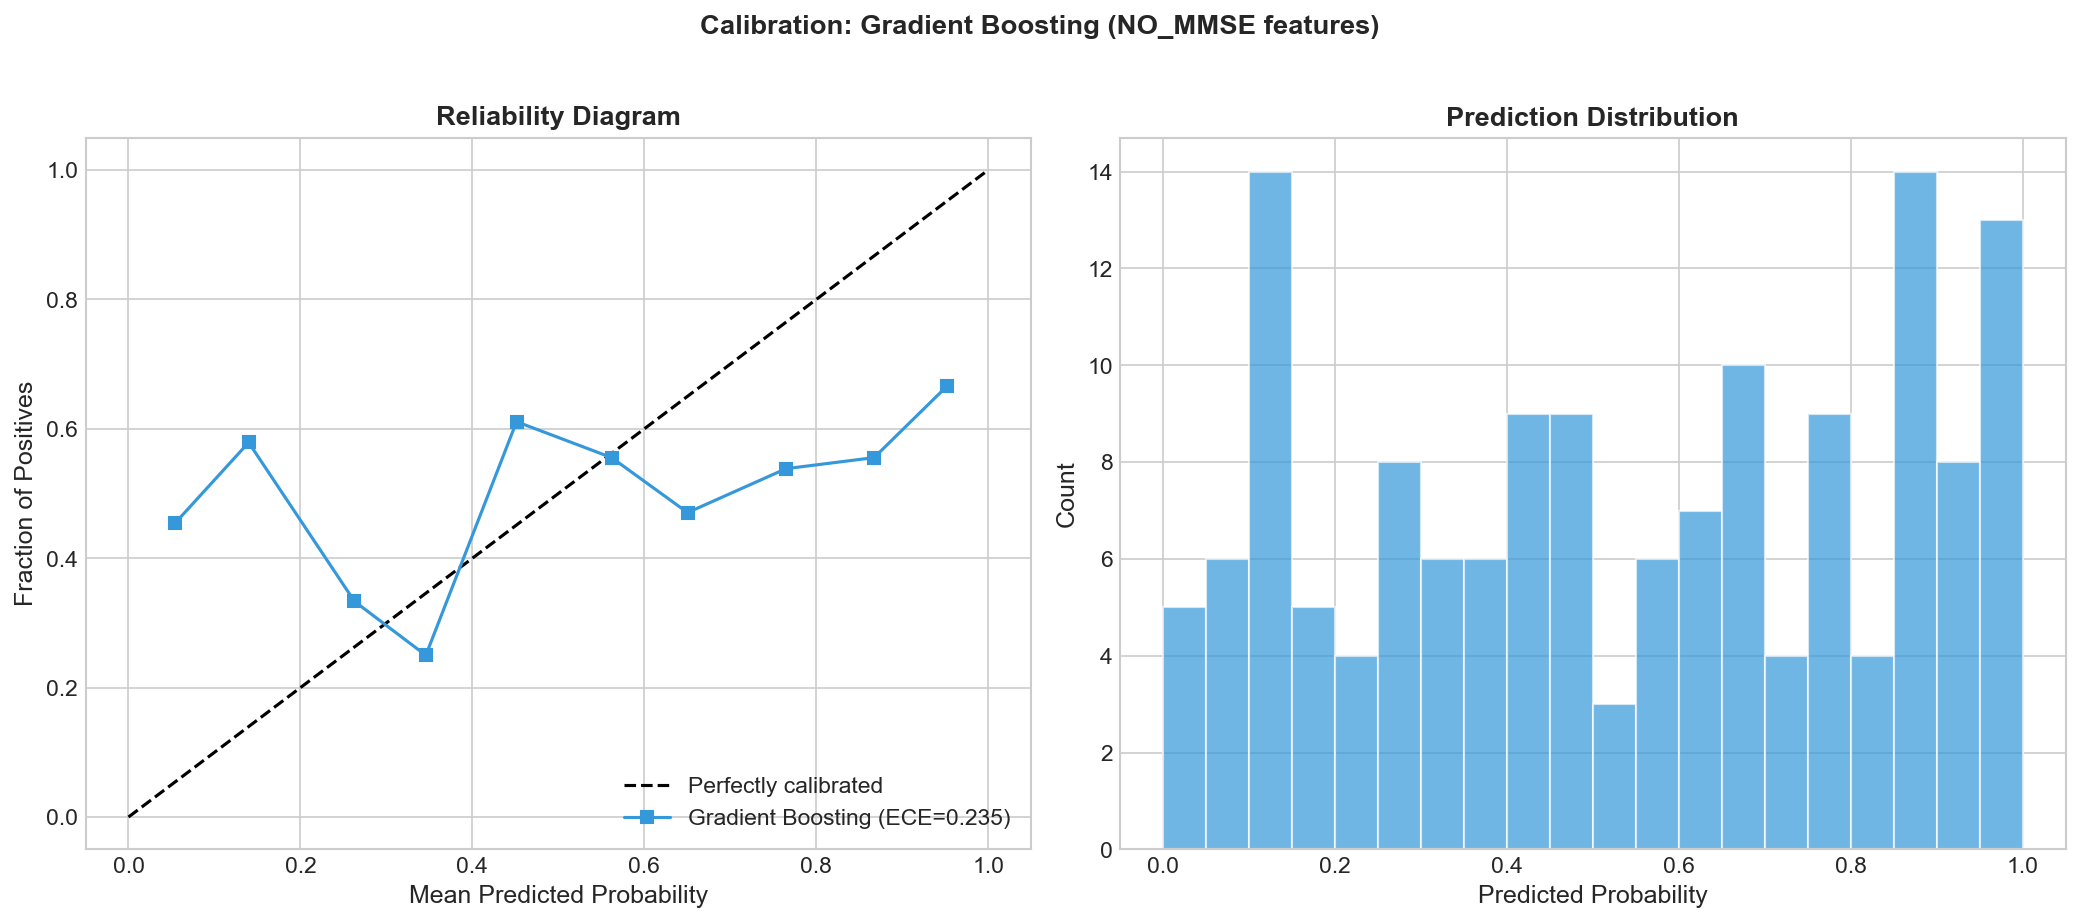

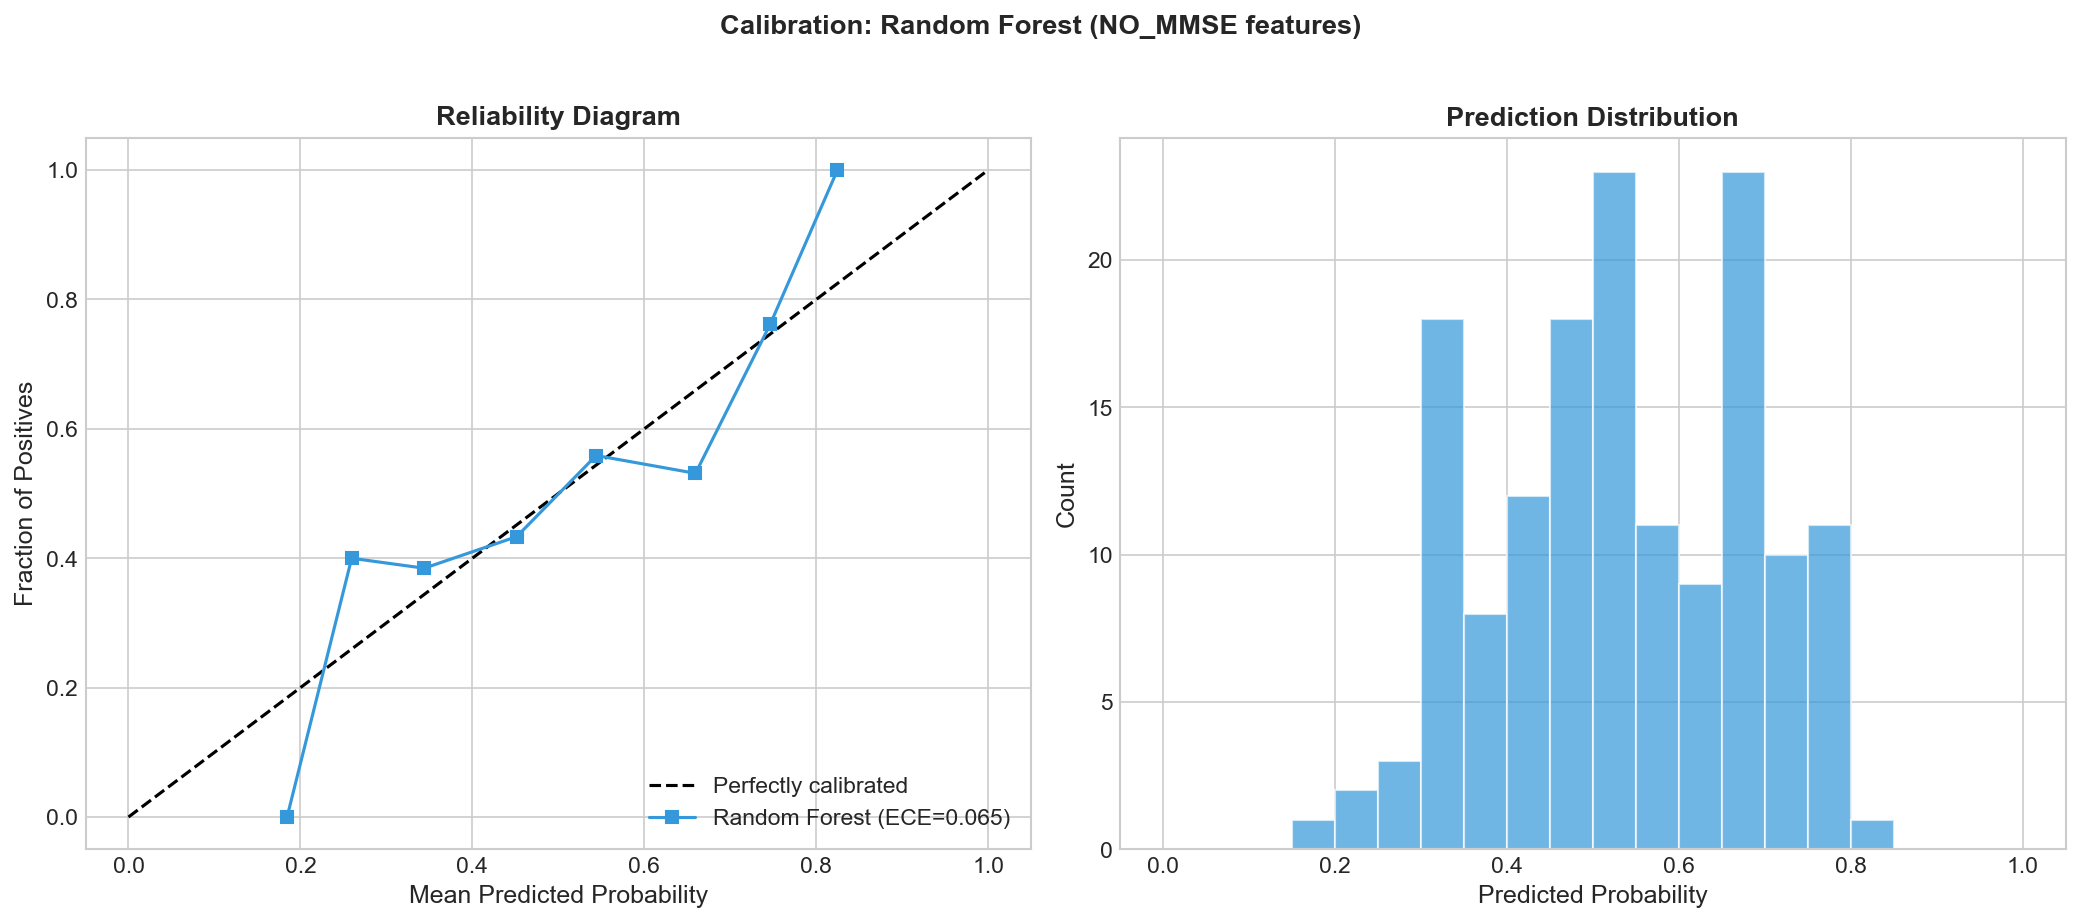

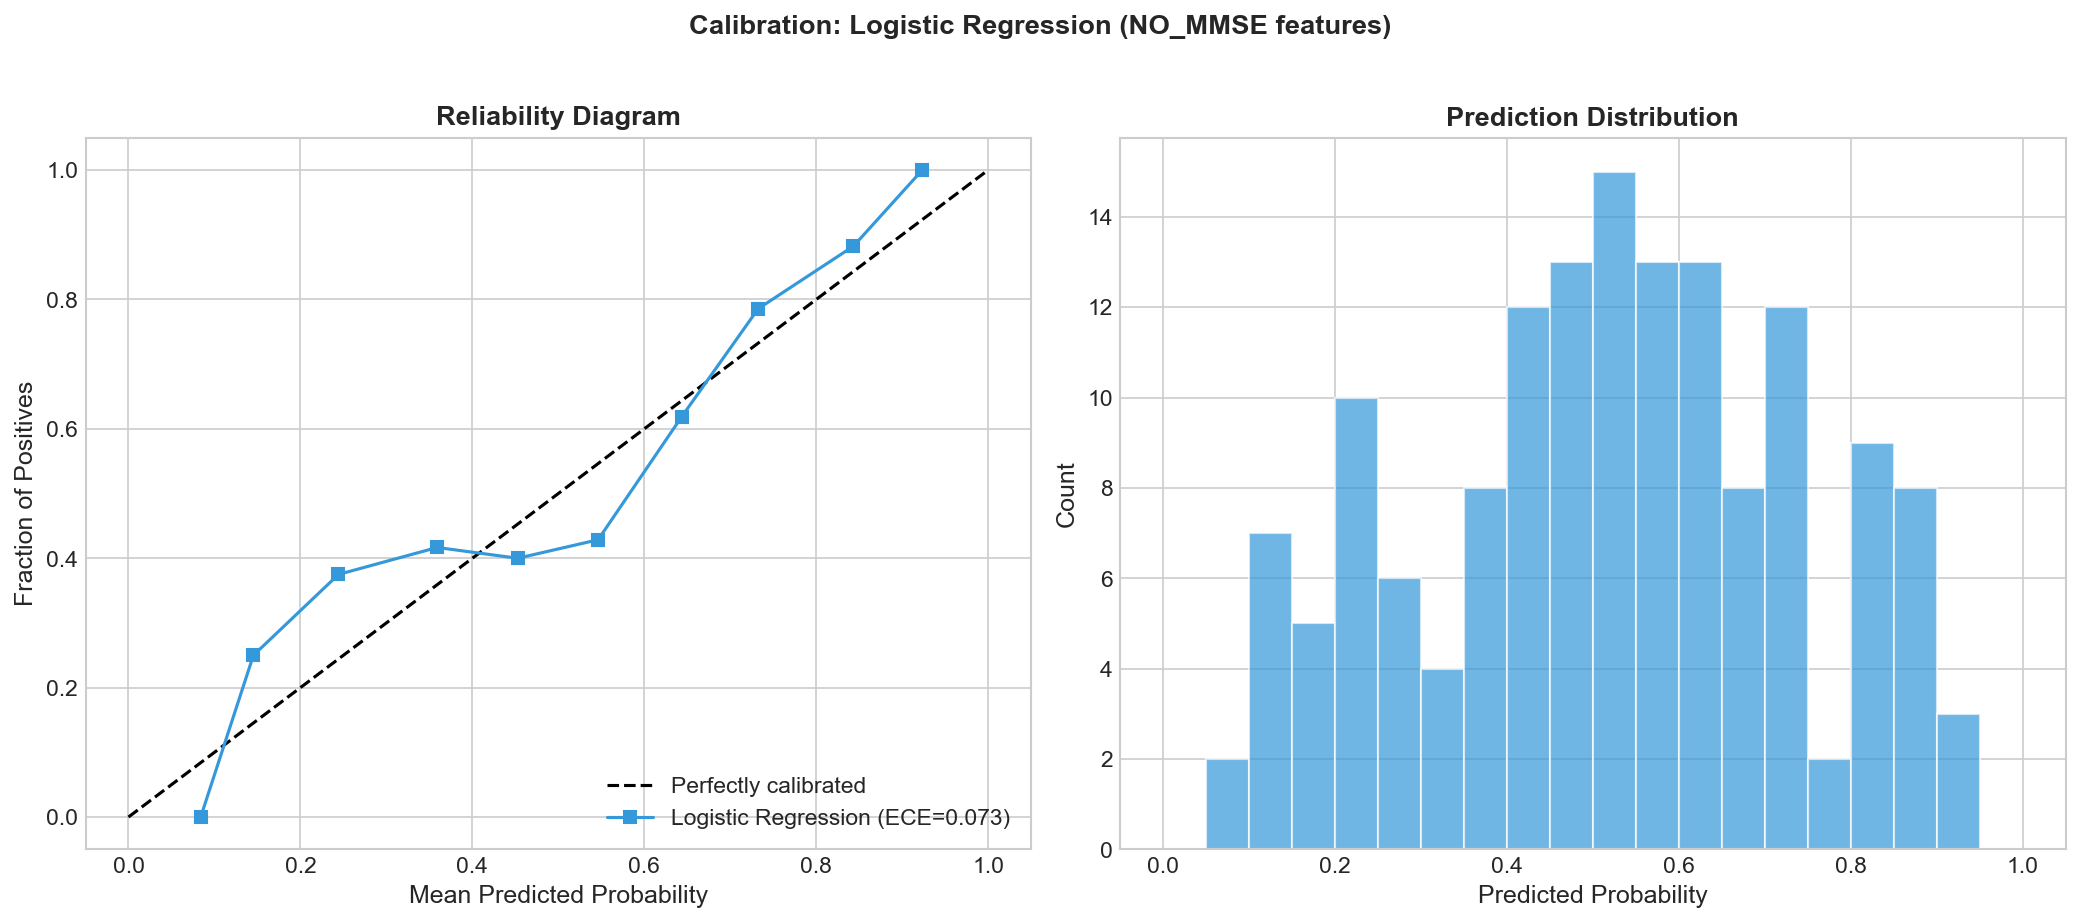

In [5]:
# Plot individual reliability diagrams for each model
for name in top3_names:
    fig = plot_calibration(calibration_results[name], model_name=name)
    fig.suptitle(f"Calibration: {name} (NO_MMSE features)", fontweight="bold", y=1.02)
    save_figure(fig, f"calibration_{name.lower().replace(' ', '_')}")
    plt.show()

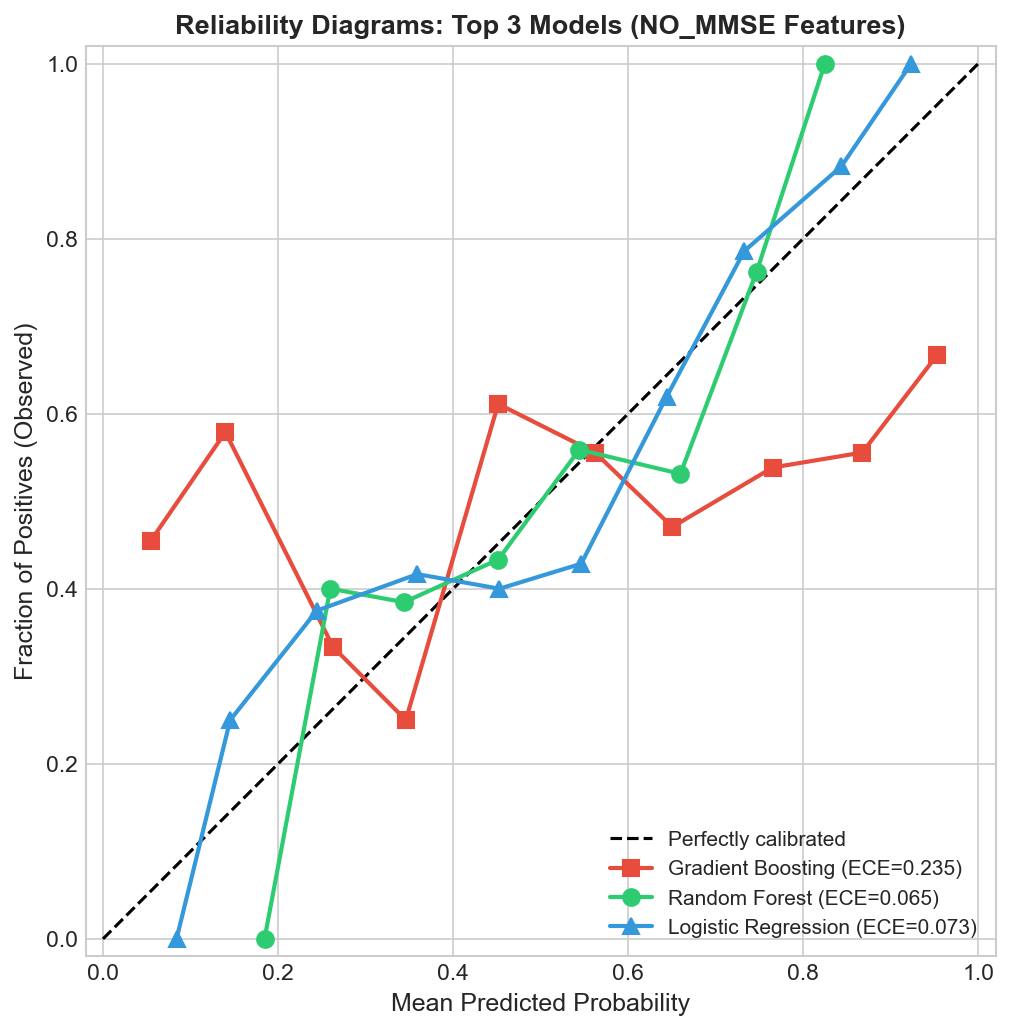

In [6]:
# Combined reliability diagram for comparison
set_style()
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfectly calibrated")

colors = {"Gradient Boosting": "#e74c3c", "Random Forest": "#2ecc71", "Logistic Regression": "#3498db"}
markers = {"Gradient Boosting": "s", "Random Forest": "o", "Logistic Regression": "^"}

for name in top3_names:
    res = calibration_results[name]
    ax.plot(
        res["mean_predicted_value"],
        res["fraction_of_positives"],
        marker=markers[name],
        linestyle="-",
        color=colors[name],
        label=f"{name} (ECE={res['ece']:.3f})",
        linewidth=2,
        markersize=8,
    )

ax.set_xlabel("Mean Predicted Probability", fontsize=12)
ax.set_ylabel("Fraction of Positives (Observed)", fontsize=12)
ax.set_title("Reliability Diagrams: Top 3 Models (NO_MMSE Features)", fontweight="bold", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")

save_figure(fig, "calibration_comparison")
plt.show()

**Interpretation:**

- The model closest to the diagonal is best calibrated.
- Logistic Regression is often well-calibrated by construction (it optimizes log-loss).
- Tree-based models (Gradient Boosting, Random Forest) can be miscalibrated because they
  optimize classification boundaries, not probability estimates.
- ECE quantifies the gap: lower = closer to diagonal = more trustworthy probabilities.

---
## 3. Conformal Prediction

Conformal prediction provides **prediction sets** with **guaranteed coverage**.

Instead of saying "this patient is demented" (a point prediction), conformal prediction says:
- At alpha=0.10: "We are **90% confident** the true label is in {Demented}" (singleton set = confident)
- At alpha=0.05: "We are **95% confident** the true label is in {Nondemented, Demented}" (full set = uncertain)

**Key insight:**
- **Singleton set** (size 1): the model is confident in a single class
- **Full set** (size 2): the model is uncertain - both classes are plausible
- Higher coverage demands (lower alpha) produce larger sets (more conservative)

In [7]:
# Run conformal prediction for the best model (Gradient Boosting)
best_model = models["Gradient Boosting"]
alpha_levels = [0.05, 0.10]

conformal_results = conformal_prediction(
    best_model, X_no_mmse, y, alpha_levels=alpha_levels
)

print("=== Conformal Prediction Results (Gradient Boosting, NO_MMSE) ===")
print()
for alpha in alpha_levels:
    res = conformal_results[alpha]
    coverage_pct = (1 - alpha) * 100
    print(f"--- alpha={alpha:.2f} ({coverage_pct:.0f}% target coverage) ---")
    print(f"  Empirical coverage:     {res['coverage']:.3f} ({res['coverage']*100:.1f}%)")
    print(f"  Average set size:       {res['avg_set_size']:.3f}")
    print(f"  Singleton fraction:     {res['singleton_fraction']:.3f} ({res['singleton_fraction']*100:.1f}%)")
    print(f"  Conformal threshold:    {res['threshold']:.3f}")
    print()

=== Conformal Prediction Results (Gradient Boosting, NO_MMSE) ===

--- alpha=0.05 (95% target coverage) ---
  Empirical coverage:     0.947 (94.7%)
  Average set size:       1.860
  Singleton fraction:     0.140 (14.0%)
  Conformal threshold:    0.936

--- alpha=0.10 (90% target coverage) ---
  Empirical coverage:     0.900 (90.0%)
  Average set size:       1.740
  Singleton fraction:     0.260 (26.0%)
  Conformal threshold:    0.885



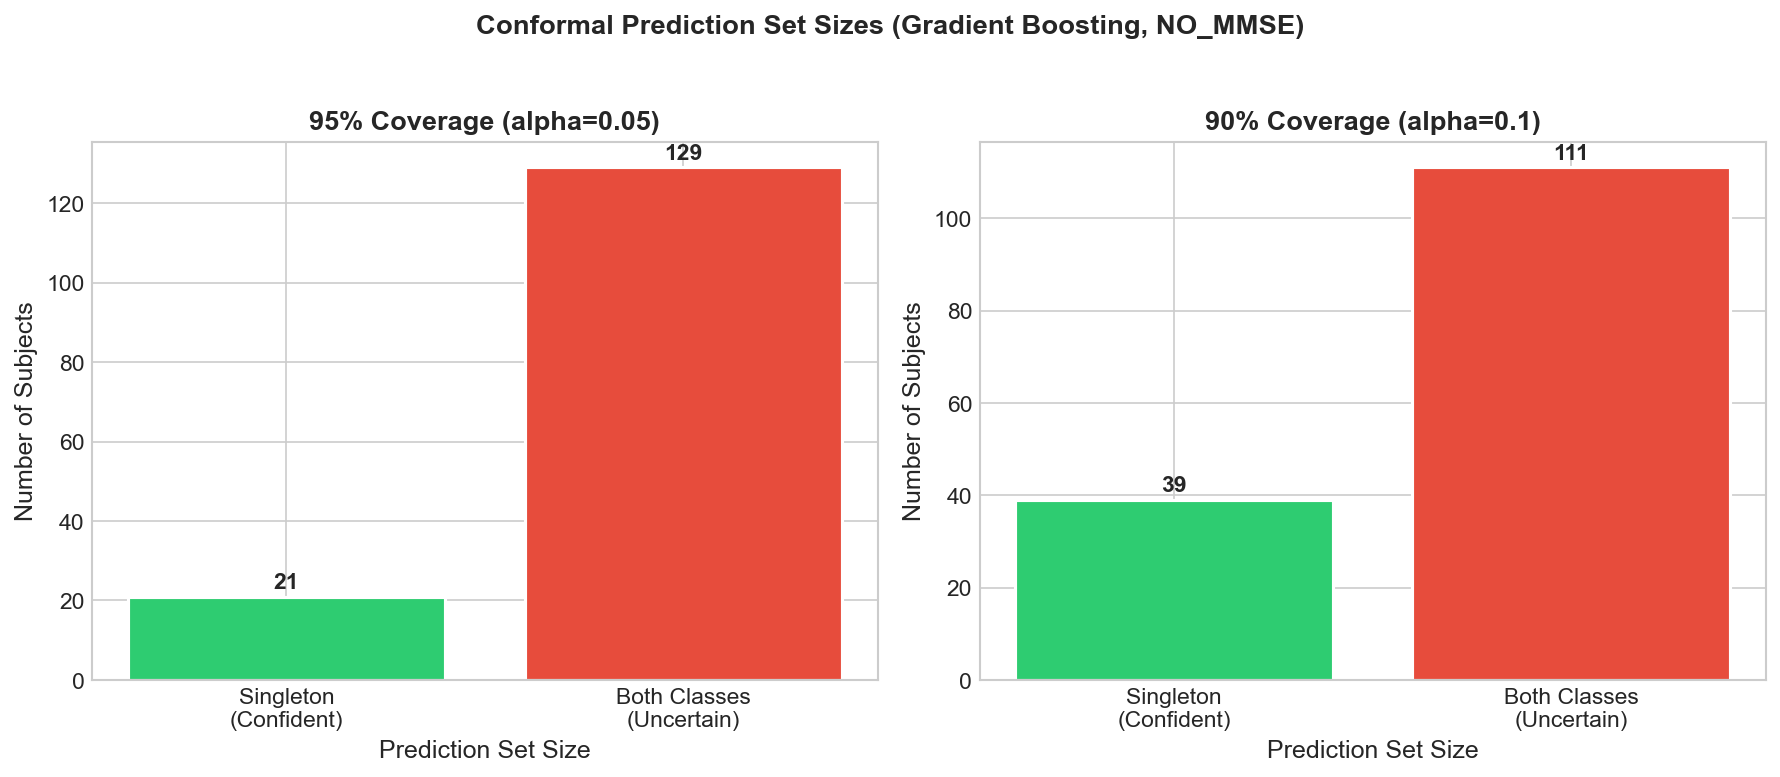

In [8]:
# Distribution of prediction set sizes
set_style()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, alpha in enumerate(alpha_levels):
    ax = axes[idx]
    res = conformal_results[alpha]
    set_sizes = [len(pset) for pset in res["prediction_sets"]]
    coverage_pct = (1 - alpha) * 100

    # Count sizes
    size_counts = pd.Series(set_sizes).value_counts().sort_index()
    bar_colors = ["#2ecc71" if s == 1 else "#e74c3c" for s in size_counts.index]

    ax.bar(size_counts.index, size_counts.values, color=bar_colors, edgecolor="white", linewidth=1.5)

    for i, (size, count) in enumerate(zip(size_counts.index, size_counts.values)):
        ax.text(size, count + 1, str(count), ha="center", va="bottom", fontweight="bold")

    ax.set_xlabel("Prediction Set Size")
    ax.set_ylabel("Number of Subjects")
    ax.set_title(f"{coverage_pct:.0f}% Coverage (alpha={alpha})", fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Singleton\n(Confident)", "Both Classes\n(Uncertain)"])

fig.suptitle("Conformal Prediction Set Sizes (Gradient Boosting, NO_MMSE)", fontweight="bold", y=1.03)

save_figure(fig, "conformal_set_sizes")
plt.show()

**Interpretation:**

- Green bars (singleton sets): the model is confident about a single class.
- Red bars (size-2 sets): the model cannot distinguish between Nondemented and Demented for
  these subjects -- both are plausible at the requested confidence level.
- As we demand higher coverage (95% vs. 90%), more subjects fall into the "uncertain" category.
  This is the **cost of higher confidence**: we must admit uncertainty more often.
- The key guarantee: the true label is in the prediction set at least (1-alpha)% of the time.

---
## 4. Bayesian Stacking

Instead of picking a single best model, Bayesian stacking assigns **weights** to each model
based on their cross-validated log-likelihoods. Models that produce better-calibrated probability
estimates get higher weights.

This is different from accuracy-based model selection: a model can have high accuracy but
poor probability estimates (and thus low stacking weight).

In [9]:
# Bayesian stacking weights for all 4 models on NO_MMSE features
stacking_results = bayesian_stacking_weights(models, X_no_mmse, y)

print("=== Bayesian Stacking Weights (NO_MMSE Features) ===")
print()
weights_df = pd.DataFrame({
    "Model": list(stacking_results["weights"].keys()),
    "Weight": list(stacking_results["weights"].values()),
    "Log-Likelihood": list(stacking_results["log_likelihoods"].values()),
}).sort_values("Weight", ascending=False)

weights_df["Weight_Pct"] = (weights_df["Weight"] * 100).round(1)
weights_df

=== Bayesian Stacking Weights (NO_MMSE Features) ===



,Model,Weight,Log-Likelihood,Weight_Pct
2,Logistic Regression,9.941333e-01,-93.118954,99.4
3,SVM,5.024538e-03,-98.406492,0.5
1,Random Forest,8.421139e-04,-100.192665,0.1
0,Gradient Boosting,2.935228e-19,-135.785402,0.0


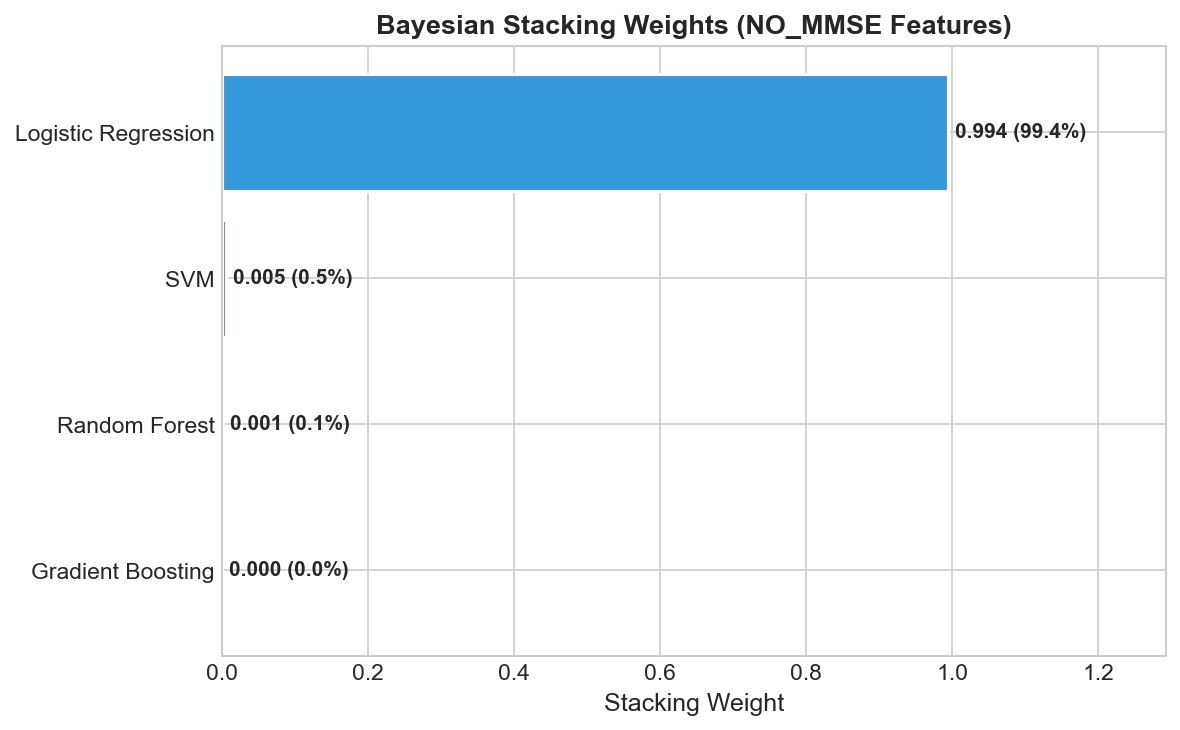

In [10]:
# Bar chart of stacking weights
set_style()
fig, ax = plt.subplots(figsize=(8, 5))

model_colors_map = {
    "Gradient Boosting": "#e74c3c",
    "Random Forest": "#2ecc71",
    "Logistic Regression": "#3498db",
    "SVM": "#9b59b6",
}

w_sorted = weights_df.sort_values("Weight", ascending=True)
bar_colors = [model_colors_map.get(m, "#95a5a6") for m in w_sorted["Model"]]

bars = ax.barh(w_sorted["Model"], w_sorted["Weight"], color=bar_colors, edgecolor="white", linewidth=1.5)

for bar, weight in zip(bars, w_sorted["Weight"]):
    ax.text(
        bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
        f"{weight:.3f} ({weight*100:.1f}%)",
        va="center", fontsize=10, fontweight="bold",
    )

ax.set_xlabel("Stacking Weight", fontsize=12)
ax.set_title("Bayesian Stacking Weights (NO_MMSE Features)", fontweight="bold", fontsize=13)
ax.set_xlim(0, max(w_sorted["Weight"]) * 1.3)

save_figure(fig, "bayesian_stacking_weights")
plt.show()

**Interpretation:**

- The model with the highest weight produces the most trustworthy probability estimates
  (highest cross-validated log-likelihood).
- This is a *probabilistic* assessment of model quality, not just classification accuracy.
- If one model dominates, the ensemble degenerates to single-model selection.
  If weights are spread out, the models contribute complementary information.

---
## 5. Clinical Decision Thresholds

In clinical practice, the decision threshold matters enormously:

- **Screening threshold**: Maximize **sensitivity** (catch most cases, accept some false positives).
  Use when the cost of missing a case is high and confirmatory testing is available.
  Target: sensitivity > 0.90.

- **Confirmatory threshold**: Maximize **specificity** (few false positives, accept some missed cases).
  Use when the label carries significant consequences (treatment, stigma, insurance).
  Target: specificity > 0.90.

We plot sensitivity vs. specificity across thresholds (NOT an ROC curve -- this is threshold-indexed).

In [11]:
# Get cross-validated probabilities for the best model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_mmse)

y_proba_cv = cross_val_predict(
    models["Gradient Boosting"], X_scaled, y, cv=cv, method="predict_proba"
)[:, 1]

print(f"Cross-validated probability predictions: {len(y_proba_cv)} subjects")
print(f"Probability range: [{y_proba_cv.min():.3f}, {y_proba_cv.max():.3f}]")
print(f"Mean probability: {y_proba_cv.mean():.3f}")

Cross-validated probability predictions: 150 subjects
Probability range: [0.011, 0.992]
Mean probability: 0.536


In [12]:
# Compute clinical decision metrics at many thresholds
thresholds = np.arange(0.10, 0.95, 0.05).tolist()
clinical_df = clinical_decision_thresholds(y, y_proba_cv, thresholds=thresholds)

print("=== Clinical Decision Thresholds ===")
clinical_df.round(3)

=== Clinical Decision Thresholds ===


,threshold,sensitivity,specificity,ppv,npv,accuracy
0,0.10,0.936,0.083,0.525,0.545,0.527
1,0.15,0.833,0.167,0.520,0.480,0.513
2,0.20,0.795,0.194,0.517,0.467,0.507
3,0.25,0.769,0.222,0.517,0.471,0.507
4,0.30,0.744,0.306,0.537,0.524,0.533
5,0.35,0.731,0.375,0.559,0.562,0.560
6,0.40,0.705,0.431,0.573,0.574,0.573
7,0.45,0.628,0.472,0.563,0.540,0.553
8,0.50,0.564,0.528,0.564,0.528,0.547
9,0.55,0.551,0.556,0.573,0.533,0.553


In [13]:
# Identify screening and confirmatory thresholds
screening_candidates = clinical_df[clinical_df["sensitivity"] >= 0.90]
if len(screening_candidates) > 0:
    screening_row = screening_candidates.loc[screening_candidates["threshold"].idxmax()]
    screening_threshold = screening_row["threshold"]
else:
    screening_threshold = clinical_df.loc[clinical_df["sensitivity"].idxmax(), "threshold"]
    screening_row = clinical_df[clinical_df["threshold"] == screening_threshold].iloc[0]

confirmatory_candidates = clinical_df[clinical_df["specificity"] >= 0.90]
if len(confirmatory_candidates) > 0:
    confirmatory_row = confirmatory_candidates.loc[confirmatory_candidates["threshold"].idxmin()]
    confirmatory_threshold = confirmatory_row["threshold"]
else:
    confirmatory_threshold = clinical_df.loc[clinical_df["specificity"].idxmax(), "threshold"]
    confirmatory_row = clinical_df[clinical_df["threshold"] == confirmatory_threshold].iloc[0]

print(f"=== Screening Threshold: {screening_threshold:.2f} ===")
print(f"  Sensitivity: {screening_row['sensitivity']:.3f}")
print(f"  Specificity: {screening_row['specificity']:.3f}")
print(f"  PPV:         {screening_row['ppv']:.3f}")
print(f"  NPV:         {screening_row['npv']:.3f}")
print(f"  Accuracy:    {screening_row['accuracy']:.3f}")
print()
print(f"=== Confirmatory Threshold: {confirmatory_threshold:.2f} ===")
print(f"  Sensitivity: {confirmatory_row['sensitivity']:.3f}")
print(f"  Specificity: {confirmatory_row['specificity']:.3f}")
print(f"  PPV:         {confirmatory_row['ppv']:.3f}")
print(f"  NPV:         {confirmatory_row['npv']:.3f}")
print(f"  Accuracy:    {confirmatory_row['accuracy']:.3f}")

=== Screening Threshold: 0.10 ===
  Sensitivity: 0.936
  Specificity: 0.083
  PPV:         0.525
  NPV:         0.545
  Accuracy:    0.527

=== Confirmatory Threshold: 0.90 ===
  Sensitivity: 0.179
  Specificity: 0.903
  PPV:         0.667
  NPV:         0.504
  Accuracy:    0.527


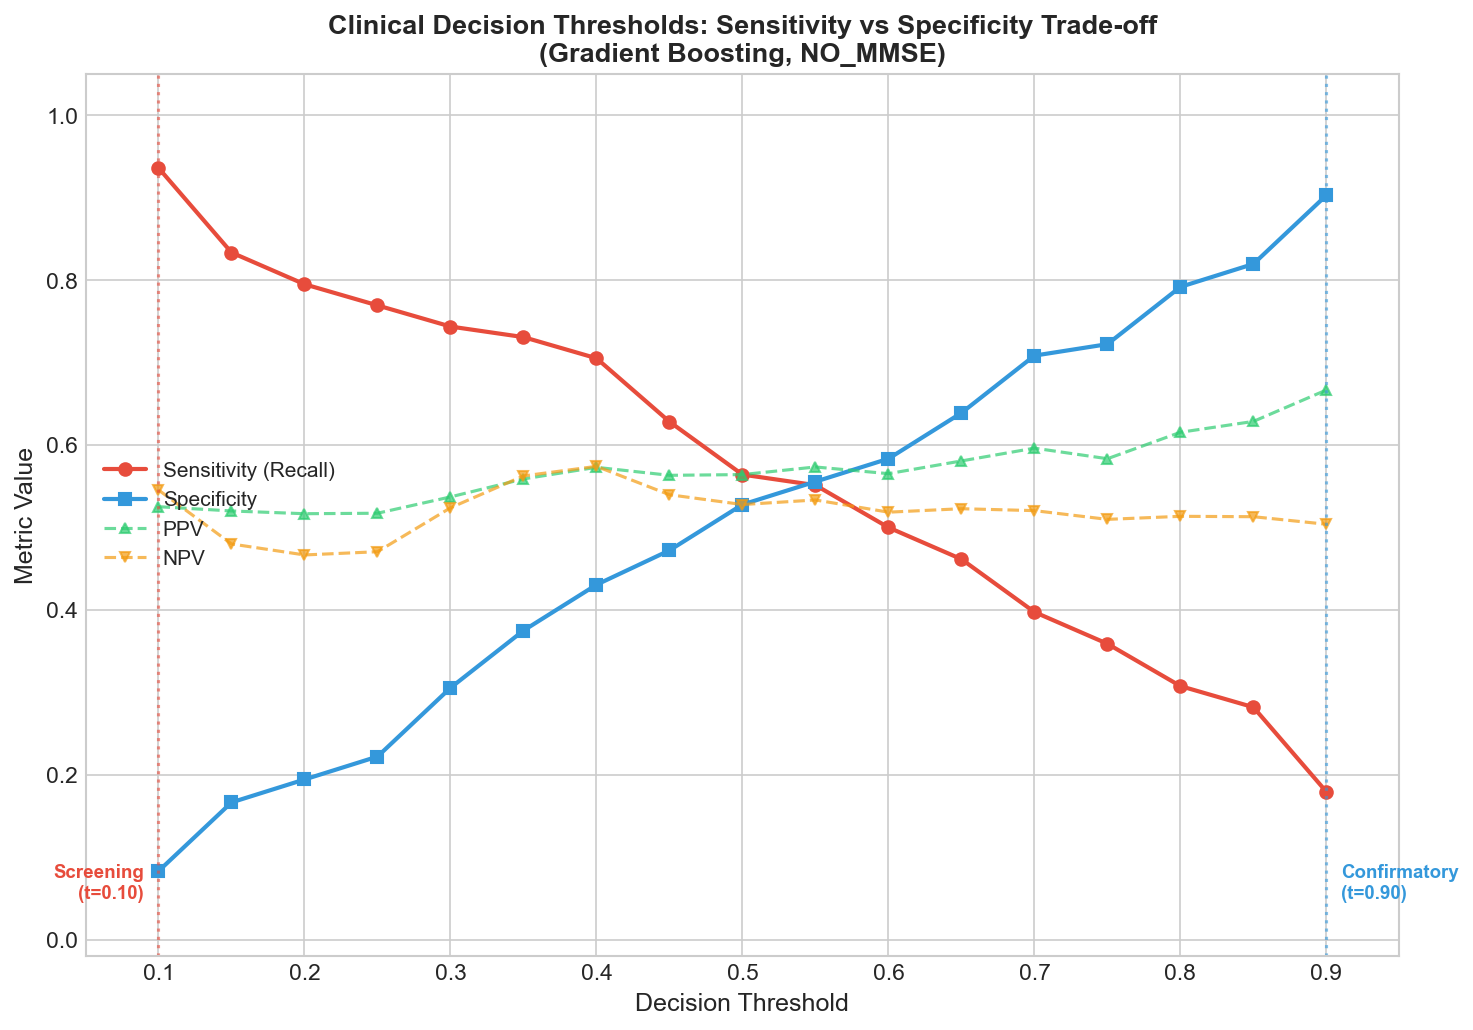

In [14]:
# Plot sensitivity vs specificity trade-off curve (threshold-indexed, NOT ROC)
set_style()
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    clinical_df["threshold"], clinical_df["sensitivity"],
    "o-", color="#e74c3c", linewidth=2, markersize=6, label="Sensitivity (Recall)",
)
ax.plot(
    clinical_df["threshold"], clinical_df["specificity"],
    "s-", color="#3498db", linewidth=2, markersize=6, label="Specificity",
)
ax.plot(
    clinical_df["threshold"], clinical_df["ppv"],
    "^--", color="#2ecc71", linewidth=1.5, markersize=5, alpha=0.7, label="PPV",
)
ax.plot(
    clinical_df["threshold"], clinical_df["npv"],
    "v--", color="#f39c12", linewidth=1.5, markersize=5, alpha=0.7, label="NPV",
)

# Mark screening threshold
ax.axvline(x=screening_threshold, color="#e74c3c", linestyle=":", alpha=0.6)
ax.text(
    screening_threshold - 0.01, 0.05,
    f"Screening\n(t={screening_threshold:.2f})",
    color="#e74c3c", fontsize=9, ha="right", fontweight="bold",
)

# Mark confirmatory threshold
ax.axvline(x=confirmatory_threshold, color="#3498db", linestyle=":", alpha=0.6)
ax.text(
    confirmatory_threshold + 0.01, 0.05,
    f"Confirmatory\n(t={confirmatory_threshold:.2f})",
    color="#3498db", fontsize=9, ha="left", fontweight="bold",
)

ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Metric Value", fontsize=12)
ax.set_title(
    "Clinical Decision Thresholds: Sensitivity vs Specificity Trade-off\n(Gradient Boosting, NO_MMSE)",
    fontweight="bold", fontsize=13,
)
ax.legend(loc="center left", fontsize=10)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(-0.02, 1.05)

save_figure(fig, "clinical_decision_thresholds")
plt.show()

In [15]:
# Clinical decision summary table
clinical_summary = pd.DataFrame([
    {
        "Use Case": "Screening",
        "Threshold": screening_threshold,
        "Sensitivity": screening_row["sensitivity"],
        "Specificity": screening_row["specificity"],
        "PPV": screening_row["ppv"],
        "NPV": screening_row["npv"],
        "Accuracy": screening_row["accuracy"],
        "Rationale": "Catch most cases; low miss rate",
    },
    {
        "Use Case": "Balanced (default 0.50)",
        "Threshold": 0.50,
        "Sensitivity": clinical_df.loc[(clinical_df["threshold"] - 0.50).abs().idxmin(), "sensitivity"],
        "Specificity": clinical_df.loc[(clinical_df["threshold"] - 0.50).abs().idxmin(), "specificity"],
        "PPV": clinical_df.loc[(clinical_df["threshold"] - 0.50).abs().idxmin(), "ppv"],
        "NPV": clinical_df.loc[(clinical_df["threshold"] - 0.50).abs().idxmin(), "npv"],
        "Accuracy": clinical_df.loc[(clinical_df["threshold"] - 0.50).abs().idxmin(), "accuracy"],
        "Rationale": "Standard balanced threshold",
    },
    {
        "Use Case": "Confirmatory",
        "Threshold": confirmatory_threshold,
        "Sensitivity": confirmatory_row["sensitivity"],
        "Specificity": confirmatory_row["specificity"],
        "PPV": confirmatory_row["ppv"],
        "NPV": confirmatory_row["npv"],
        "Accuracy": confirmatory_row["accuracy"],
        "Rationale": "High confidence positive; few false alarms",
    },
])

print("=== Clinical Decision Table ===")
clinical_summary.round(3)

=== Clinical Decision Table ===


,Use Case,Threshold,Sensitivity,Specificity,PPV,NPV,Accuracy,Rationale
0,Screening,0.1,0.936,0.083,0.525,0.545,0.527,Catch most cases; low miss rate
1,Balanced (default 0.50),0.5,0.564,0.528,0.564,0.528,0.547,Standard balanced threshold
2,Confirmatory,0.9,0.179,0.903,0.667,0.504,0.527,High confidence positive; few false alarms


In [16]:
# Save clinical decision table
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
clinical_summary.to_csv(RESULTS_TABLES / "clinical_decision_thresholds.csv", index=False)
print(f"Saved: {RESULTS_TABLES / 'clinical_decision_thresholds.csv'}")

Saved: /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/results/tables/clinical_decision_thresholds.csv


---
## 6. Uncertainty by Subgroup

Are uncertain predictions clinically meaningful? We examine conformal prediction set sizes
stratified by:
- **Nondemented subjects** (y=0)
- **Demented subjects** (y=1)
- **Subjects near the decision boundary** (predicted probability between 0.3 and 0.7)

Hypothesis: subjects near the boundary (ambiguous cases) should have larger prediction sets
(more uncertainty), while clearly demented or nondemented subjects should have singletons.

In [17]:
# Analyze set sizes by subgroup at alpha=0.10 (90% coverage)
alpha_analysis = 0.10
res = conformal_results[alpha_analysis]
set_sizes = np.array([len(pset) for pset in res["prediction_sets"]])

# Subgroup masks
nondemented_mask = y == 0
demented_mask = y == 1
boundary_mask = (y_proba_cv >= 0.3) & (y_proba_cv <= 0.7)
confident_mask = ~boundary_mask

print(f"=== Uncertainty by Subgroup (alpha={alpha_analysis}, {(1-alpha_analysis)*100:.0f}% coverage) ===")
print()

subgroups = {
    "Nondemented (y=0)": nondemented_mask,
    "Demented (y=1)": demented_mask,
    "Near boundary (p in [0.3, 0.7])": boundary_mask,
    "Confident (p outside [0.3, 0.7])": confident_mask,
}

subgroup_rows = []
for name, mask in subgroups.items():
    n_subjects = mask.sum()
    if n_subjects == 0:
        continue
    avg_size = set_sizes[mask].mean()
    singleton_frac = (set_sizes[mask] == 1).mean()
    uncertain_frac = (set_sizes[mask] == 2).mean()
    subgroup_rows.append({
        "Subgroup": name,
        "N": n_subjects,
        "Avg Set Size": avg_size,
        "Singleton %": singleton_frac * 100,
        "Uncertain %": uncertain_frac * 100,
    })

subgroup_df = pd.DataFrame(subgroup_rows)
subgroup_df.round(1)

=== Uncertainty by Subgroup (alpha=0.1, 90% coverage) ===



,Subgroup,N,Avg Set Size,Singleton %,Uncertain %
0,Nondemented (y=0),72,1.8,19.4,80.6
1,Demented (y=1),78,1.7,32.1,67.9
2,"Near boundary (p in [0.3, 0.7])",56,2.0,0.0,100.0
3,"Confident (p outside [0.3, 0.7])",94,1.6,41.5,58.5


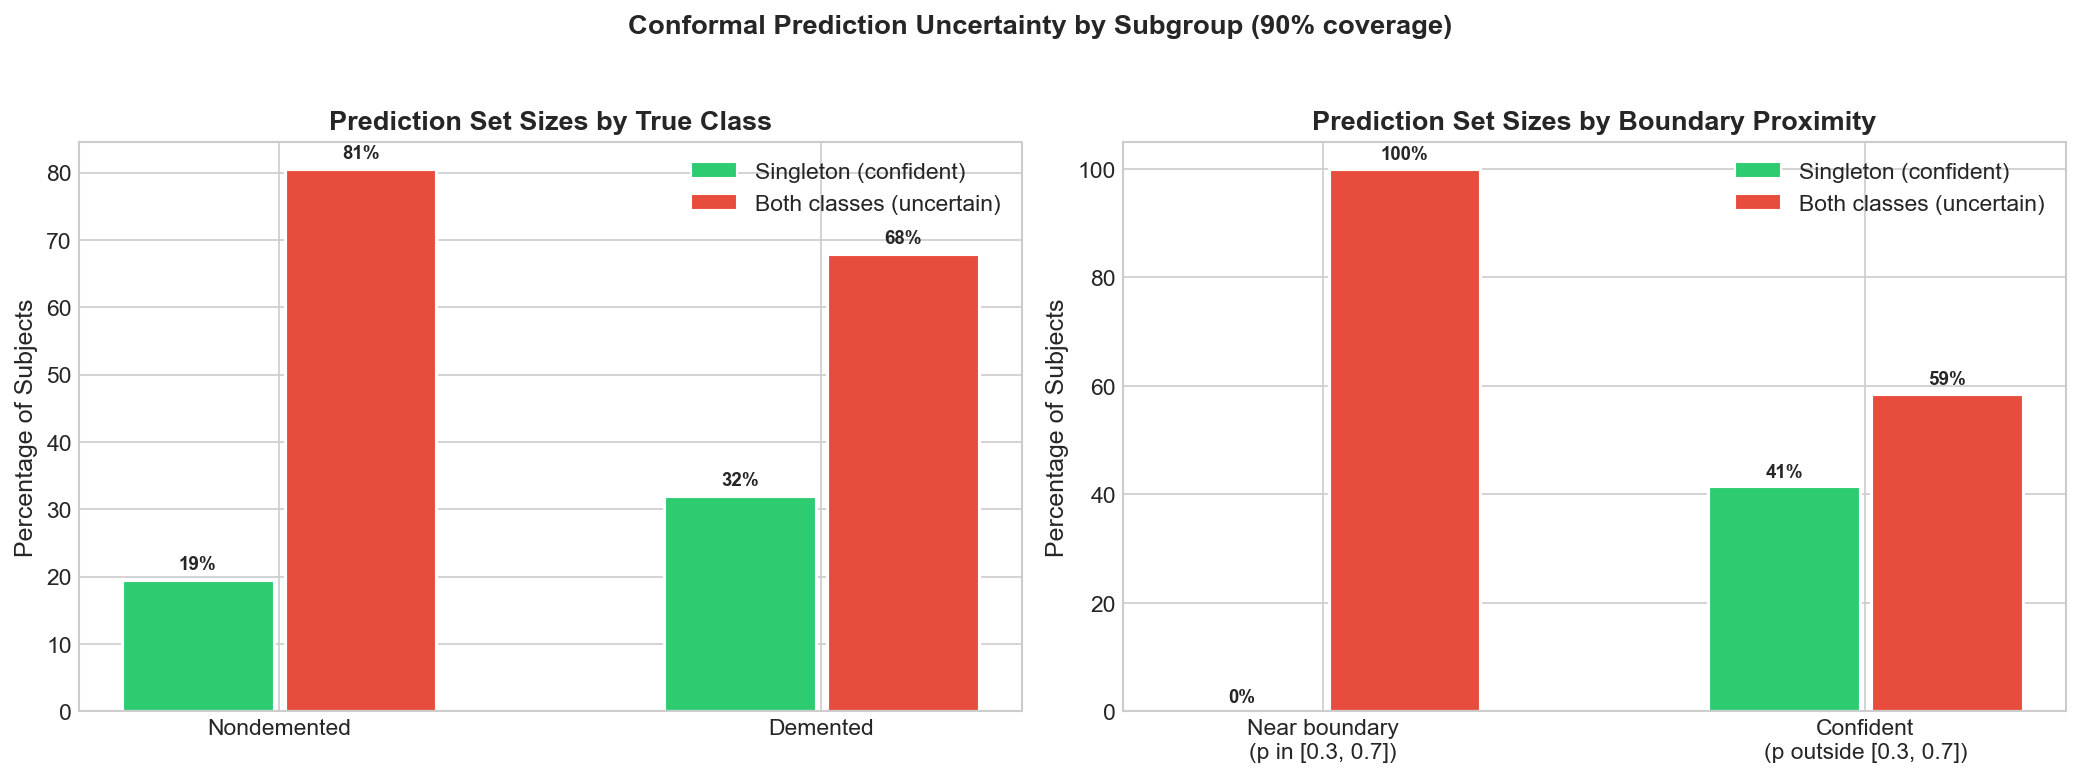

In [18]:
# Visualize uncertainty by subgroup
set_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: set size distribution by true class
ax = axes[0]
class_labels = ["Nondemented", "Demented"]
for i, (label, mask) in enumerate([("Nondemented", nondemented_mask), ("Demented", demented_mask)]):
    sizes = set_sizes[mask]
    singleton_pct = (sizes == 1).mean() * 100
    uncertain_pct = (sizes == 2).mean() * 100
    bars = ax.bar(
        [i - 0.15, i + 0.15],
        [singleton_pct, uncertain_pct],
        width=0.28,
        color=["#2ecc71", "#e74c3c"],
        edgecolor="white",
        linewidth=1.5,
    )
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height:.0f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(range(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_ylabel("Percentage of Subjects")
ax.set_title("Prediction Set Sizes by True Class", fontweight="bold")
legend_elements = [
    mpatches.Patch(facecolor="#2ecc71", edgecolor="white", label="Singleton (confident)"),
    mpatches.Patch(facecolor="#e74c3c", edgecolor="white", label="Both classes (uncertain)"),
]
ax.legend(handles=legend_elements, loc="upper right")

# Right: set size distribution by decision boundary proximity
ax = axes[1]
boundary_labels = ["Near boundary\n(p in [0.3, 0.7])", "Confident\n(p outside [0.3, 0.7])"]
for i, (label, mask) in enumerate([("Boundary", boundary_mask), ("Confident", confident_mask)]):
    if mask.sum() == 0:
        continue
    sizes = set_sizes[mask]
    singleton_pct = (sizes == 1).mean() * 100
    uncertain_pct = (sizes == 2).mean() * 100
    bars = ax.bar(
        [i - 0.15, i + 0.15],
        [singleton_pct, uncertain_pct],
        width=0.28,
        color=["#2ecc71", "#e74c3c"],
        edgecolor="white",
        linewidth=1.5,
    )
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height:.0f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(range(len(boundary_labels)))
ax.set_xticklabels(boundary_labels)
ax.set_ylabel("Percentage of Subjects")
ax.set_title("Prediction Set Sizes by Boundary Proximity", fontweight="bold")
ax.legend(handles=legend_elements, loc="upper right")

fig.suptitle(
    f"Conformal Prediction Uncertainty by Subgroup ({(1-alpha_analysis)*100:.0f}% coverage)",
    fontweight="bold", y=1.03,
)

save_figure(fig, "uncertainty_by_subgroup")
plt.show()

**Interpretation:**

- Subjects near the decision boundary are more likely to have size-2 prediction sets (uncertain).
  This is clinically meaningful: these are the patients who need additional workup.
- Clearly demented or nondemented subjects tend to have singleton sets (confident predictions).
- The conformal framework correctly identifies *where* the model is unsure, which can guide
  clinical workflow (e.g., refer uncertain cases for specialist evaluation).

---
## 7. Comparison: With vs. Without MMSE

MMSE is near-circular with CDR-derived dementia labels. Including it should *trivially*
reduce uncertainty (smaller prediction sets). This comparison demonstrates why the
NO_MMSE feature set is the honest evaluation setting.

In [19]:
# Conformal prediction WITH all features (including MMSE)
conformal_all = conformal_prediction(
    models["Gradient Boosting"], X_all, y, alpha_levels=[0.05, 0.10]
)

print("=== Conformal Prediction Comparison: ALL vs NO_MMSE Features ===")
print()
comparison_rows = []
for alpha in [0.05, 0.10]:
    coverage_pct = (1 - alpha) * 100

    res_no_mmse = conformal_results[alpha]
    res_all = conformal_all[alpha]

    comparison_rows.append({
        "Coverage": f"{coverage_pct:.0f}%",
        "Feature Set": "NO_MMSE",
        "Avg Set Size": res_no_mmse["avg_set_size"],
        "Singleton %": res_no_mmse["singleton_fraction"] * 100,
        "Coverage Achieved": res_no_mmse["coverage"],
    })
    comparison_rows.append({
        "Coverage": f"{coverage_pct:.0f}%",
        "Feature Set": "ALL (with MMSE)",
        "Avg Set Size": res_all["avg_set_size"],
        "Singleton %": res_all["singleton_fraction"] * 100,
        "Coverage Achieved": res_all["coverage"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.round(3)

=== Conformal Prediction Comparison: ALL vs NO_MMSE Features ===



,Coverage,Feature Set,Avg Set Size,Singleton %,Coverage Achieved
0,95%,NO_MMSE,1.860,14.000,0.947
1,95%,ALL (with MMSE),1.553,44.667,0.947
2,90%,NO_MMSE,1.740,26.000,0.900
3,90%,ALL (with MMSE),1.393,60.667,0.900


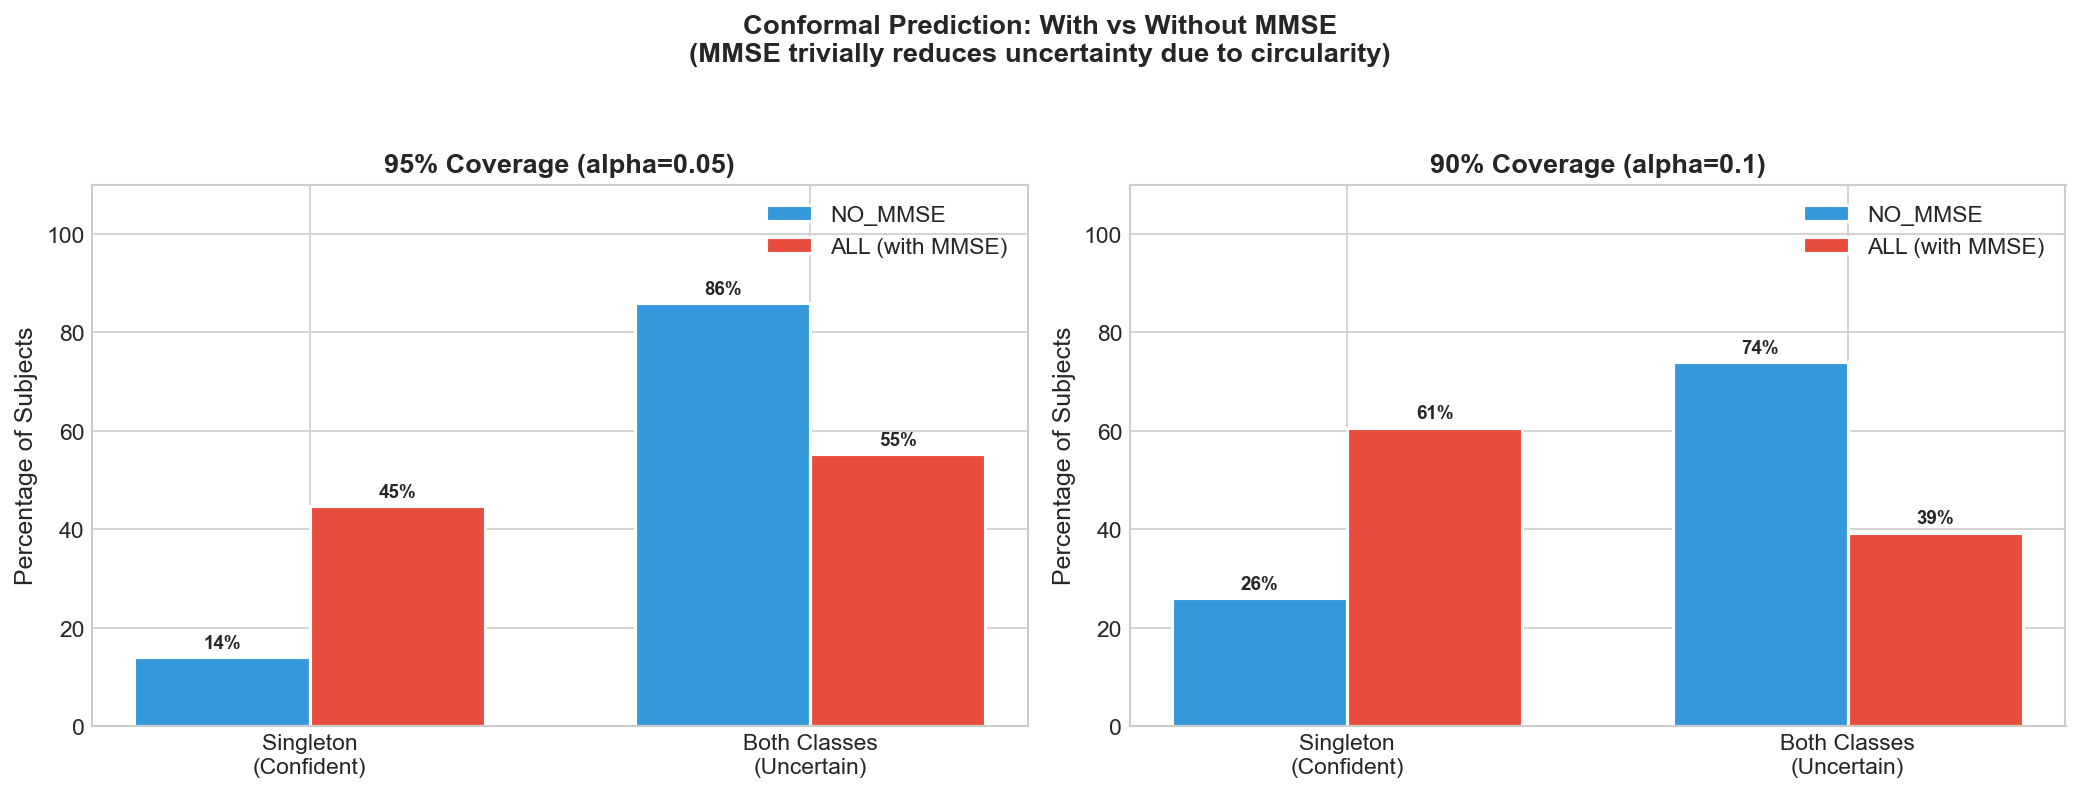

In [20]:
# Visualize the comparison
set_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, alpha in enumerate([0.05, 0.10]):
    ax = axes[idx]
    coverage_pct = (1 - alpha) * 100

    no_mmse_sizes = [len(pset) for pset in conformal_results[alpha]["prediction_sets"]]
    all_sizes = [len(pset) for pset in conformal_all[alpha]["prediction_sets"]]

    no_mmse_singleton = np.mean(np.array(no_mmse_sizes) == 1) * 100
    no_mmse_uncertain = np.mean(np.array(no_mmse_sizes) == 2) * 100
    all_singleton = np.mean(np.array(all_sizes) == 1) * 100
    all_uncertain = np.mean(np.array(all_sizes) == 2) * 100

    x = np.arange(2)
    width = 0.35

    bars1 = ax.bar(x - width/2, [no_mmse_singleton, no_mmse_uncertain],
                   width, label="NO_MMSE", color="#3498db", edgecolor="white", linewidth=1.5)
    bars2 = ax.bar(x + width/2, [all_singleton, all_uncertain],
                   width, label="ALL (with MMSE)", color="#e74c3c", edgecolor="white", linewidth=1.5)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height:.0f}%",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(["Singleton\n(Confident)", "Both Classes\n(Uncertain)"])
    ax.set_ylabel("Percentage of Subjects")
    ax.set_title(f"{coverage_pct:.0f}% Coverage (alpha={alpha})", fontweight="bold")
    ax.legend()
    ax.set_ylim(0, 110)

fig.suptitle(
    "Conformal Prediction: With vs Without MMSE\n(MMSE trivially reduces uncertainty due to circularity)",
    fontweight="bold", y=1.05,
)

save_figure(fig, "conformal_mmse_comparison")
plt.show()

**Interpretation:**

- Including MMSE dramatically reduces prediction set sizes (more singletons, fewer uncertain predictions).
- This is expected and **not evidence of a better model**. MMSE is near-circular with the CDR-derived
  dementia label. Including it is essentially leaking the answer into the features.
- The NO_MMSE results represent honest uncertainty about whether demographics + MRI alone
  can distinguish demented from nondemented subjects.
- This reinforces why the NO_MMSE feature set is the scientifically appropriate evaluation setting.

---
## 8. Key Findings

### Calibration Quality
- Expected Calibration Error (ECE) quantifies how trustworthy probability estimates are.
- Logistic Regression tends to be best-calibrated (it directly optimizes log-loss).
- Tree-based models may need post-hoc calibration (Platt scaling or isotonic regression)
  if probability estimates are used for clinical decisions.

### What Conformal Sets Tell Us
- Conformal prediction provides **distribution-free** coverage guarantees.
- At 90% coverage, a substantial fraction of subjects get singleton prediction sets
  (the model is confident). The remaining subjects get both classes (model is uncertain).
- Uncertain predictions cluster near the decision boundary and among subjects that are
  genuinely hard to classify from demographics + MRI alone.
- This is clinically actionable: uncertain cases can be flagged for additional workup.

### Recommended Clinical Thresholds
- **Screening** (high sensitivity): use a low threshold to catch most cases.
  Accept higher false positive rate; refer positives for confirmatory testing.
- **Confirmatory** (high specificity): use a high threshold to minimize false positives.
  Accept missing some cases; appropriate when the diagnosis carries significant consequences.
- The optimal threshold depends on the clinical context, not just model performance.

### Honest Uncertainty Characterization
- With demographics + MRI features only (no MMSE), the model has genuine uncertainty
  for a non-trivial fraction of subjects.
- Including MMSE *trivially* resolves this uncertainty because MMSE is near-circular
  with the CDR-derived label -- this is **not** a legitimate reduction in clinical uncertainty.
- Bayesian stacking weights reflect which models produce the most trustworthy probabilities,
  not just which achieve the highest accuracy.
- All uncertainty estimates should be interpreted in the context of n=150 subjects with
  class imbalance -- a larger dataset would provide tighter conformal sets.

In [21]:
# Save all key results
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)

# ECE table
ece_df.to_csv(RESULTS_TABLES / "calibration_ece.csv", index=False)

# Conformal prediction summary
conformal_summary_rows = []
for alpha in alpha_levels:
    res = conformal_results[alpha]
    conformal_summary_rows.append({
        "alpha": alpha,
        "target_coverage": 1 - alpha,
        "empirical_coverage": res["coverage"],
        "avg_set_size": res["avg_set_size"],
        "singleton_fraction": res["singleton_fraction"],
    })
pd.DataFrame(conformal_summary_rows).to_csv(
    RESULTS_TABLES / "conformal_prediction_summary.csv", index=False
)

# Stacking weights
weights_df.to_csv(RESULTS_TABLES / "bayesian_stacking_weights.csv", index=False)

# Subgroup uncertainty
subgroup_df.to_csv(RESULTS_TABLES / "uncertainty_by_subgroup.csv", index=False)

# MMSE comparison
comparison_df.to_csv(RESULTS_TABLES / "conformal_mmse_comparison.csv", index=False)

print("=== Results Saved ===")
print(f"  {RESULTS_TABLES / 'calibration_ece.csv'}")
print(f"  {RESULTS_TABLES / 'conformal_prediction_summary.csv'}")
print(f"  {RESULTS_TABLES / 'bayesian_stacking_weights.csv'}")
print(f"  {RESULTS_TABLES / 'clinical_decision_thresholds.csv'}")
print(f"  {RESULTS_TABLES / 'uncertainty_by_subgroup.csv'}")
print(f"  {RESULTS_TABLES / 'conformal_mmse_comparison.csv'}")
print()
print("=== Figures Saved ===")
print(f"  {RESULTS_FIGURES / 'calibration_*.png'}")
print(f"  {RESULTS_FIGURES / 'conformal_set_sizes.png'}")
print(f"  {RESULTS_FIGURES / 'bayesian_stacking_weights.png'}")
print(f"  {RESULTS_FIGURES / 'clinical_decision_thresholds.png'}")
print(f"  {RESULTS_FIGURES / 'uncertainty_by_subgroup.png'}")
print(f"  {RESULTS_FIGURES / 'conformal_mmse_comparison.png'}")

=== Results Saved ===
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/results/tables/calibration_ece.csv
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/results/tables/conformal_prediction_summary.csv
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/results/tables/bayesian_stacking_weights.csv
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/results/tables/clinical_decision_thresholds.csv
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/results/tables/uncertainty_by_subgroup.csv
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/results/tables/conformal_mmse_comparison.csv

=== Figures Saved ===
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/results/figures/calibration_*.png
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/results/figures/conformal_set_sizes.png
  /Users/abiskaracharya/P